## Iteration 1: Data Loading, EDA, Preprocessing & Baseline MLP Model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.exceptions import ConvergenceWarning

# Set global visualization style
sns.set_theme(style="whitegrid")

# 1. Load the dataset
# Ensure 'water_potability.csv' is in your working directory
df = pd.read_csv("water_potability.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Missing values per column prior to imputation:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


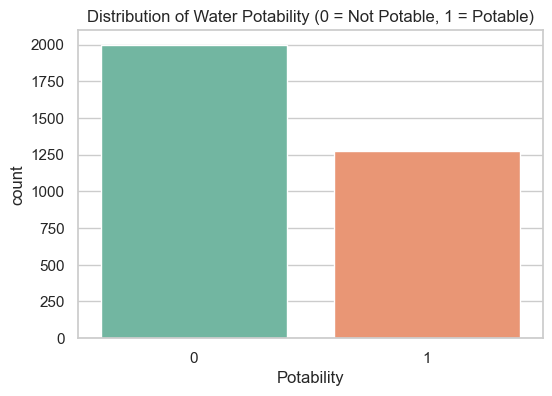


Class distribution ratios:
Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


In [3]:
# 2. Exploratory Data Analysis & Class Balance
print("Missing values per column prior to imputation:")
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, hue='Potability', palette='Set2', legend=False)
plt.title('Distribution of Water Potability (0 = Not Potable, 1 = Potable)')
plt.show()

print("\nClass distribution ratios:")
print(df['Potability'].value_counts(normalize=True))

In [4]:
# 3. Safe Missing Value Imputation & Train-Test Split
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

print("Missing values after robust median imputation:", df_clean.isnull().sum().sum())

X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Missing values after robust median imputation: 0
Train set size: 2620, Test set size: 656


In [5]:
# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training baseline MLP model...

================ BASELINE PERFORMANCE ================
Accuracy:  0.6387
Precision: 0.5525
Recall:    0.3906


c:\Users\xyz\Github\BIAI\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


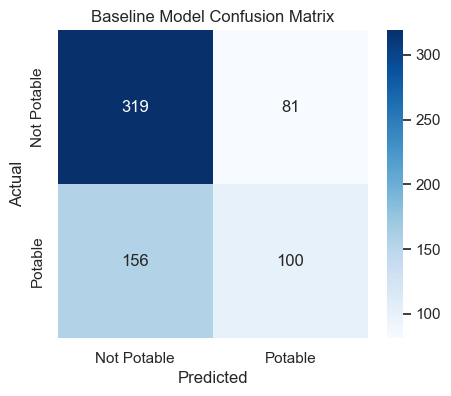

In [6]:
# 5. Baseline MLP Model Training & Evaluation
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64,), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)

print("Training baseline MLP model...")
mlp_baseline.fit(X_train_scaled, y_train)

y_pred = mlp_baseline.predict(X_test_scaled)

# Save scores for final comparison
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n================ BASELINE PERFORMANCE ================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("======================================================")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Baseline Model Confusion Matrix')
plt.show()

---  
## Iteration 2: Feature Space Reduction (Correlation & Feature Importance Analysis)

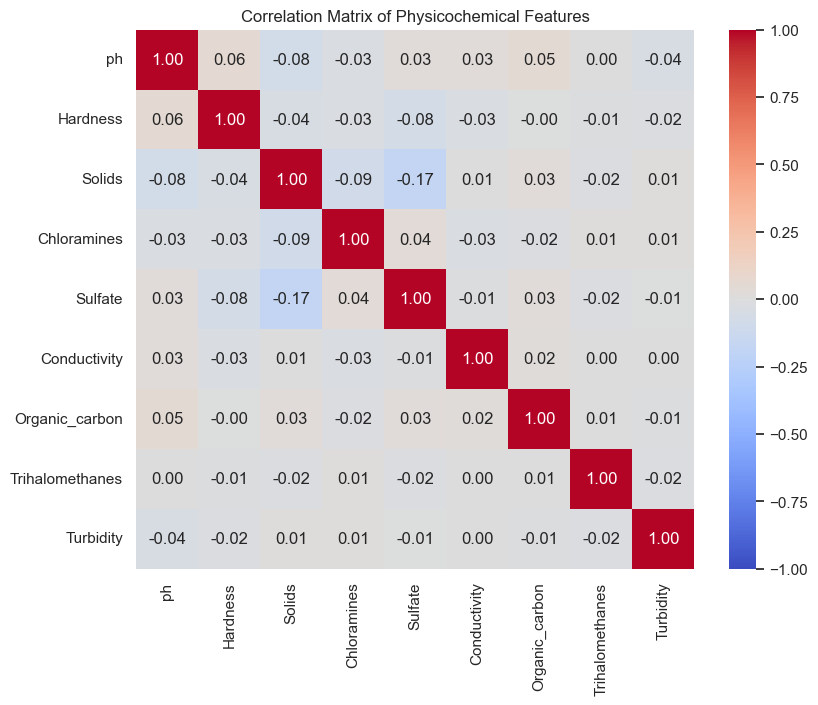

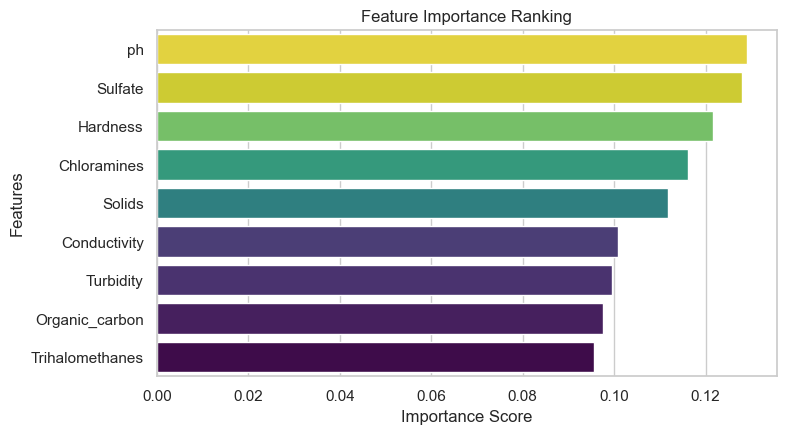

        Feature  Importance
             ph    0.129132
        Sulfate    0.127858
       Hardness    0.121633
    Chloramines    0.116048
         Solids    0.111863
   Conductivity    0.100752
      Turbidity    0.099522
 Organic_carbon    0.097521
Trihalomethanes    0.095672


In [7]:
# 1. Correlation Matrix Analysis
plt.figure(figsize=(9, 7))
corr_matrix = pd.DataFrame(X_train_scaled, columns=X.columns).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Physicochemical Features")
plt.show()

# 2. Feature Importance Ranking via Random Forest Proxy
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(hue='Importance', x='Importance', y='Feature', data=feature_imp_df, palette='viridis', legend=False)
plt.title('Feature Importance Ranking')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print(feature_imp_df.to_string(index=False))

Dropping lowest impact features: ['Turbidity', 'Trihalomethanes']

================ REDUCED MODEL PERFORMANCE ================
Accuracy:  0.6768 (Baseline: 0.6387)
Precision: 0.6467 (Baseline: 0.5525)
Recall:    0.3789 (Baseline: 0.3906)


c:\Users\xyz\Github\BIAI\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


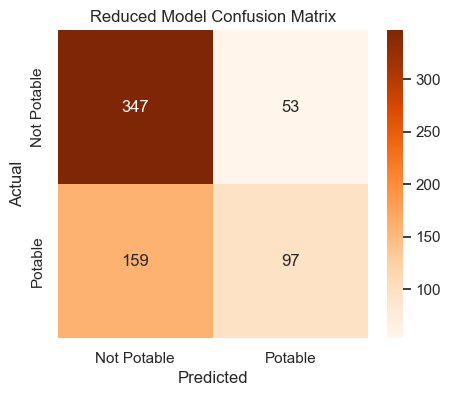

In [8]:
# 3. Drop Lowest Impact Features & Re-train
features_to_drop = ['Turbidity', 'Trihalomethanes']
print(f"Dropping lowest impact features: {features_to_drop}")

feature_names = list(X.columns)
keep_indices = [feature_names.index(col) for col in feature_names if col not in features_to_drop]

X_train_reduced = X_train_scaled[:, keep_indices]
X_test_reduced = X_test_scaled[:, keep_indices]

mlp_reduced = MLPClassifier(
    hidden_layer_sizes=(64,), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)
mlp_reduced.fit(X_train_reduced, y_train)

y_pred_reduced = mlp_reduced.predict(X_test_reduced)
accuracy_red = accuracy_score(y_test, y_pred_reduced)
precision_red = precision_score(y_test, y_pred_reduced)
recall_red = recall_score(y_test, y_pred_reduced)

print("\n================ REDUCED MODEL PERFORMANCE ================")
print(f"Accuracy:  {accuracy_red:.4f} (Baseline: {accuracy:.4f})")
print(f"Precision: {precision_red:.4f} (Baseline: {precision:.4f})")
print(f"Recall:    {recall_red:.4f} (Baseline: {recall:.4f})")
print("===========================================================")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_reduced), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Reduced Model Confusion Matrix')
plt.show()

---  
## Iteration 3: Hyperparameter Tuning via Comprehensive Grid Search

In [9]:
# 1. Setup Grid Search Validation Architecture
warnings.filterwarnings("ignore", category=ConvergenceWarning)

param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [800]  # Increased to guarantee full algorithmic convergence
}

print("Executing Hyperparameter Optimization Grid Search...")
mlp_tune = MLPClassifier(solver='adam', random_state=42)

grid_search = GridSearchCV(
    estimator=mlp_tune, 
    param_grid=param_grid, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)
grid_search.fit(X_train_reduced, y_train)

print("\n================ GRID SEARCH RESULTS ================")
print("Best Hyperparameters Found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print("=====================================================")

Executing Hyperparameter Optimization Grid Search...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

================ GRID SEARCH RESULTS ================
Best Hyperparameters Found:
{'activation': 'relu', 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'max_iter': 800}
Best Cross-Validation Accuracy: 0.6702



================ OPTIMIZED MODEL PERFORMANCE ================
Accuracy:  0.6860 (Reduced Baseline: 0.6768)
Precision: 0.6344 (Reduced Baseline: 0.6467)
Recall:    0.4609 (Reduced Baseline: 0.3789)


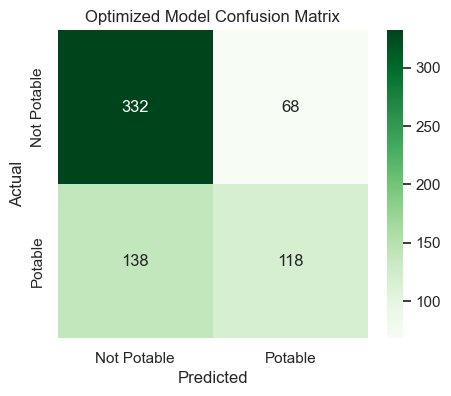

In [10]:
# 2. Extract and Evaluate the Final Optimized Model
best_mlp = grid_search.best_estimator_
y_pred_opt = best_mlp.predict(X_test_reduced)

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)

print("\n================ OPTIMIZED MODEL PERFORMANCE ================")
print(f"Accuracy:  {accuracy_opt:.4f} (Reduced Baseline: {accuracy_red:.4f})")
print(f"Precision: {precision_opt:.4f} (Reduced Baseline: {precision_red:.4f})")
print(f"Recall:    {recall_opt:.4f} (Reduced Baseline: {recall_red:.4f})")
print("=============================================================")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Optimized Model Confusion Matrix')
plt.show()

---  
## Iteration 4: Project Summary & Performance Compilation

In [11]:
# Compile metrics across all experimental cycles into a clean summary table
summary_data = {
    'Stage / Model Iteration': [
        '1. Baseline Model (All Features)', 
        '2. Reduced Model (7 Features)', 
        '3. Fully Optimized Model'
    ],
    'Accuracy': [accuracy, accuracy_red, accuracy_opt],
    'Precision': [precision, precision_red, precision_opt],
    'Recall': [recall, recall_red, recall_opt]
}

df_summary = pd.DataFrame(summary_data)
print("\n==================== FINAL PROJECT EVALUATION SUMMARY ====================")
display(df_summary.style.highlight_max(color='lightgreen', axis=0, subset=['Accuracy', 'Precision', 'Recall']))


==================== FINAL PROJECT EVALUATION SUMMARY ====================


,Stage / Model Iteration,Accuracy,Precision,Recall
0,1. Baseline Model (All Features),0.638720,0.552486,0.390625
1,2. Reduced Model (7 Features),0.676829,0.646667,0.378906
2,3. Fully Optimized Model,0.685976,0.634409,0.460938
